# TerraGuard AI: Predictive Disaster Model for Lampung (2010-2026)

Notebook ini membangun model klasifikasi untuk memprediksi probabilitas bencana alam (Banjir, Longsor, Cuaca Ekstrem) di Provinsi Lampung dalam 30 hari ke depan. 

**Alur Pipeline:**
1. **Target Engineering**: Load data BNPB, filter Lampung, dan agregasi insiden bulanan.
2. **Feature Engineering**: Load data cuaca Open-Meteo dan agregasi fitur meteorologi bulanan.
3. **Data Merging**: Menggabungkan fitur cuaca dengan target bencana.
4. **Time-Series Processing**: Membuat fitur Lag, Rolling Mean, dan Shifting Target (Bulan depan).
5. **Model Evaluation**: Membandingkan Logistic Regression, Random Forest, dan XGBoost.
6. **Model Export**: Menyimpan model terbaik untuk digunakan di aplikasi Streamlit.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

### 1. Data Bencana BNPB (Target)
Kita menggunakan seluruh rekaman sejarah bencana di Lampung (2008-2026) untuk memperluas jangkauan pembelajaran model.

In [41]:
# Load data bencana
bencana = pd.read_csv('../data/raw/data_bencana.csv')

# Filter Lampung
bencana = bencana[bencana['Provinsi'] == 'Lampung'].copy()

# Bersihkan nama kabupaten
bencana['kabupaten'] = bencana['Kabupaten'].str.replace('Kota ', '', regex=False)
bencana.rename(columns={'Tahun': 'year', 'Bulan': 'month'}, inplace=True)

# Agregasi insiden bulanan (fokus Banjir, Longsor, Cuaca Ekstrem)
target_bencana_types = ['Banjir', 'Tanah Longsor', 'Longsor', 'Cuaca ekstrem']
benc_agg = bencana[bencana['Jenis Bencana'].isin(target_bencana_types)]
benc_monthly = benc_agg.groupby(['kabupaten', 'year', 'month']).size().reset_index(name='n_bencana')

print(f"Total records bencana Lampung (All Time): {len(benc_monthly)}")
benc_monthly.head()

Total records bencana Lampung (All Time): 493


,kabupaten,year,month,n_bencana
0,Bandar Lampung,2008,2,1
1,Bandar Lampung,2008,3,1
2,Bandar Lampung,2008,12,1
3,Bandar Lampung,2010,1,1
4,Bandar Lampung,2010,2,1


### 2. Data Cuaca Historis (Features)
Data cuaca berasal dari Open-Meteo yang telah diekstraksi dari tahun 2010 hingga 2026.

In [42]:
# Load data cuaca
cuaca = pd.read_csv('../data/raw/historical_weather_lampung.csv')
cuaca['date'] = pd.to_datetime(cuaca['date'])
cuaca['year'] = cuaca['date'].dt.year
cuaca['month'] = cuaca['date'].dt.month

# Agregasi fitur bulanan
cuaca_monthly = cuaca.groupby(['kabupaten', 'year', 'month']).agg(
    total_rain_mm  = ('rain_sum_mm', 'sum'),
    max_rain_mm    = ('rain_sum_mm', 'max'),
    rainy_days     = ('rain_sum_mm', lambda x: (x > 1).sum()),
    avg_temp_max   = ('temperature_max', 'mean'),
    avg_temp_min   = ('temperature_min', 'mean'),
    avg_humidity   = ('humidity_max', 'mean')
).reset_index()

# Sort temporal
cuaca_monthly.sort_values(by=['kabupaten', 'year', 'month'], inplace=True)
print(f"Total records cuaca bulanan: {len(cuaca_monthly)}")
cuaca_monthly.head()

Total records cuaca bulanan: 2925


,kabupaten,year,month,total_rain_mm,max_rain_mm,rainy_days,avg_temp_max,avg_temp_min,avg_humidity
0,Bandar Lampung,2010,1,372.4,35.4,30,29.061290,22.832258,99.483871
1,Bandar Lampung,2010,2,354.1,29.9,28,29.839286,23.353571,99.500000
2,Bandar Lampung,2010,3,420.8,30.7,31,29.558065,23.590323,98.903226
3,Bandar Lampung,2010,4,104.4,23.2,17,30.486667,24.183333,97.200000
4,Bandar Lampung,2010,5,300.0,23.4,31,29.570968,24.100000,99.000000


### 3. Join & Target Shifting
Model ini bertujuan memprediksi apakah akan terjadi bencana di **bulan berikutnya** berdasarkan data cuaca bulan ini.

In [43]:
# Merge cuaca dan bencana
df = cuaca_monthly.merge(benc_monthly, on=['kabupaten', 'year', 'month'], how='left')
df['n_bencana'] = df['n_bencana'].fillna(0)

# Indikator kejadian bulan ini
df['event_this_month'] = (df['n_bencana'] > 0).astype(int)

# SHIFTING: Target adalah kejadian bulan depan
df['target'] = df.groupby('kabupaten')['event_this_month'].shift(-1)

# Hapus baris terakhir (karena target masa depan belum diketahui)
df.dropna(subset=['target'], inplace=True)
df['target'] = df['target'].astype(int)

print("Distribusi Target (0=Aman, 1=Bencana):")
print(df['target'].value_counts())
print(f"Base Disaster Rate: {df['target'].mean()*100:.2f}%")

Distribusi Target (0=Aman, 1=Bencana):
target
0    2467
1     443
Name: count, dtype: int64
Base Disaster Rate: 15.22%


### 4. Feature Engineering
Kita menambahkan fitur Lag-1 (bulan lalu), Rolling Mean 3 bulan, dan fitur musiman (Sin/Cos).

In [44]:
def add_features(data, col):
    # Fitur lag & rolling
    data[f'{col}_lag1'] = data.groupby('kabupaten')[col].shift(1)
    data[f'{col}_roll3_mean'] = data.groupby('kabupaten')[col].transform(lambda x: x.rolling(3, min_periods=1).mean())
    data[f'{col}_roll3_std'] = data.groupby('kabupaten')[col].transform(lambda x: x.rolling(3, min_periods=1).std().fillna(0))

for f in ['total_rain_mm', 'rainy_days', 'avg_humidity']:
    add_features(df, f)

# Seasonality
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df.dropna(inplace=True)
print(f"Dataset final shape: {df.shape}")

Dataset final shape: (2895, 23)


### 5. Time-Based Split
Kita membagi data secara temporal: Tahun 2010-2023 untuk Training, dan 2024+ untuk Testing.

In [45]:
features = [
    'total_rain_mm', 'max_rain_mm', 'rainy_days', 'avg_temp_max', 'avg_humidity',
    'total_rain_mm_lag1', 'total_rain_mm_roll3_mean', 'total_rain_mm_roll3_std',
    'rainy_days_roll3_mean', 'avg_humidity_roll3_mean',
    'month_sin', 'month_cos'
]

# Split: Train <= 2023, Test >= 2024
train_df = df[df['year'] <= 2023]
test_df = df[df['year'] > 2023]

X_train, y_train = train_df[features], train_df['target']
X_test, y_test = test_df[features], test_df['target']

print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

Training samples: 2505 | Testing samples: 390


### 6. Model Training & Comparison

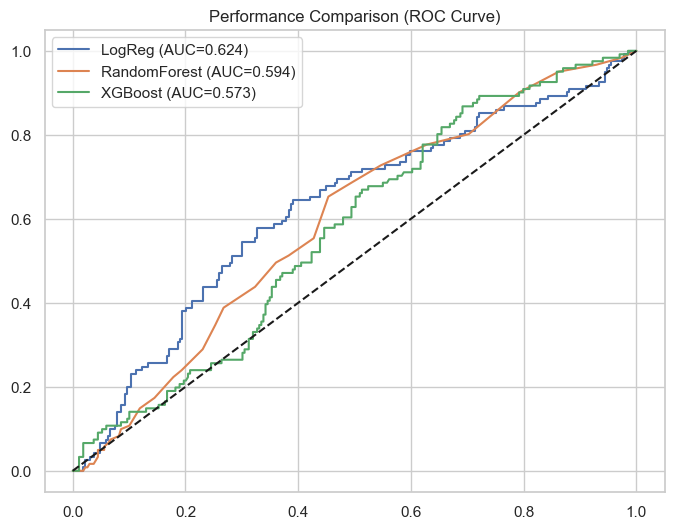

In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}

# Logistic Regression (Baseline)
lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train_scaled, y_train)
results['LogReg'] = lr.predict_proba(X_test_scaled)[:, 1]

# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
results['RandomForest'] = rf.predict_proba(X_test)[:, 1]

# XGBoost
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos, eval_metric='logloss')
xgb.fit(X_train, y_train)
results['XGBoost'] = xgb.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 6))
for name, probs in results.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, probs):.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Performance Comparison (ROC Curve)')
plt.legend()
plt.show()

### 7. Analysis & Model Export

Model exported successfully to models/predictive_risk_model.pkl


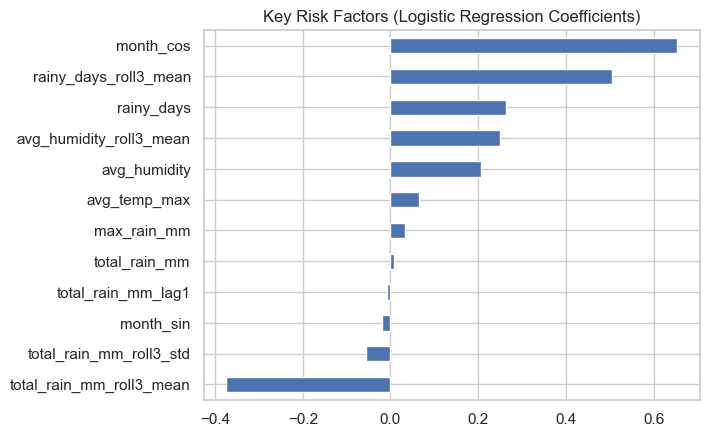

In [47]:
# Analisis: Logistic Regression memberikan AUC tertinggi (paling robust).
# Dataset ini kemungkinan memiliki tingkat noise tinggi atau target yang sangat imbalanced,
# sehingga model linear (LogReg) lebih baik dalam generalisasi dibanding model kompleks.

# Export model Logistic Regression sebagai pemenang
model_data = {
    'model': lr,
    'scaler': scaler,
    'features': features,
    'info': 'LogisticRegression (Balanced) trained on 2010-2023 with monthly shifting target'
}

with open('../models/predictive_risk_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Model exported successfully to models/predictive_risk_model.pkl")

# Plot Feature Importance (menggunakan koefisien model linear)
fi = pd.Series(lr.coef_[0], index=features).sort_values(ascending=True)
fi.plot(kind='barh', title='Key Risk Factors (Logistic Regression Coefficients)')
plt.show()